# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [1]:
#The goal of this analysis is to identify the key drivers of used car prices to help car dealers make informed inventory and pricing decisions. 
#From a data science perspective, this is a supervised learning regression problem in which the objective is to predict a continuous target variable (used car price) based on input features in the dataset.
#We aim to explore and quantify the relationships between predictors and price by performing exploratory data analysis, feature selection, and model building. 
#The resulting model will be evaluated using appropriate metrics (e.g., MSE, RMSE, MAE) and interpreted to understand which features most significantly influence used car prices.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [130]:
#Exploratory Data Analysis

#Steps to Understand the Dataset and Identify Data Quality Issues

#Understand Dataset Structure
#Review the number of rows and columns, variable names, and data types (numerical, categorical, datetime).
#Identify missing values across features and evaluate their proportions.
#Check for duplicate records and inconsistencies in the data (e.g., the same car listed multiple times).

#Examine Variable Distributions
#Perform univariate analysis using summary statistics and visualizations (histograms, bar charts) to understand the distribution, range, and variability of each feature.
#This helps detect anomalies such as extreme values or incorrect entries.

#Analyze the Target Variable (Price)
#Examine the distribution of used car prices to identify skewness, outliers, and missing values.
#This is important because the target variable directly impacts model performance and may require transformation (e.g., log transformation).

#Check for Outliers and Inconsistencies
#Detect unusual or unrealistic values (e.g., negative prices, extremely high mileage) that may indicate data entry errors or rare cases requiring special handling.

#Explore Feature Relationships with Price
#Conduct bivariate analysis to understand how each feature relates to price:
#Numerical variables: scatter plots, correlation coefficients
#Categorical variables: box plots, group-wise summaries
#This helps identify potential key drivers of used car prices.


In [55]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import train_test_split
from datetime import datetime
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#read in the dataset
used_cars = pd.read_csv("data/vehicles.csv")
used_cars.tail()

#used_cars = used_cars.sample(n=1000, random_state=42)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


In [4]:
#Understand Dataset Structure
#variable names, type, non-null values
used_cars.info()

#get a proportion of missing values
prop=used_cars.isnull().mean()
print(prop)
#higher prop of missingness seen for features like condition, cylinders, VIN, drive, size, type, and paint_color

#check for duplicate values for id
used_cars['id'].duplicated().any()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

False

In [125]:
#Examine Variable Distributions
num_cols = used_cars.select_dtypes(include=['int64', 'float64']).columns
cat_cols = used_cars.select_dtypes(include=['object']).columns
num_cols=num_cols.drop(['id'])

print(num_cols)
print(cat_cols)

Index(['price', 'year', 'odometer'], dtype='object')
Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'VIN', 'drive', 'size', 'type',
       'paint_color', 'state'],
      dtype='object')


Distribution of Price
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64
Histogram displaying the Price


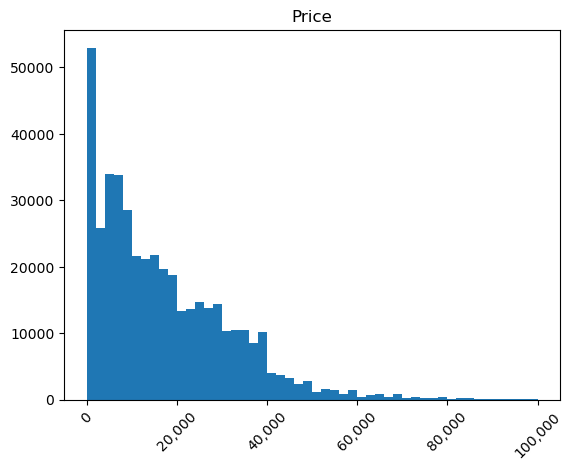

Histogram displaying the Price (Log Transformed)


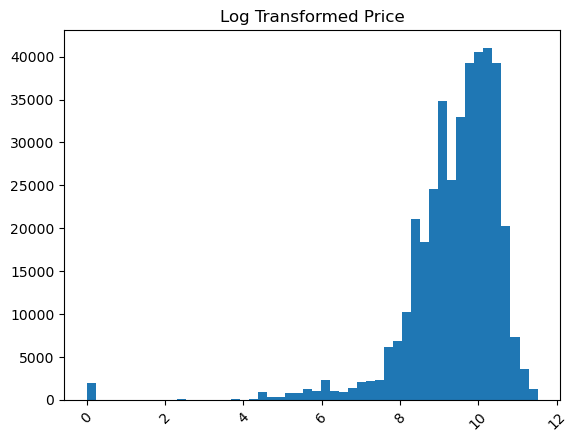

In [126]:
#Analyze the Target Variable (Price)
#used car prices to identify skewness, outliers, and missing values.

print('Distribution of Price')
print(used_cars['price'].describe())

#subsetting car price to <100000 to avoid displaying outliers
subset_cars=used_cars[used_cars['price'] < 100000]
print('Histogram displaying the Price')
plt.hist(subset_cars['price'].dropna(), bins=50)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}')) 
plt.xticks(rotation=45)
plt.title('Price')
plt.show()

#the mean price of used cars is around 7500 and the price distribution is right skewed

##plotting the log trannsformed price
subset_cars=used_cars[used_cars['price'] < 100000]
log_price = np.log(subset_cars['price'][subset_cars['price'] > 0])

print('Histogram displaying the Price (Log Transformed)')
plt.hist(log_price.dropna(), bins=50)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}')) 
plt.xticks(rotation=45)
plt.title('Log Transformed Price')
plt.show()

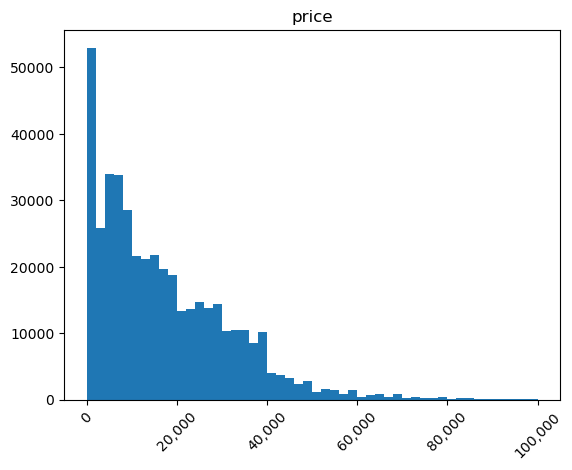

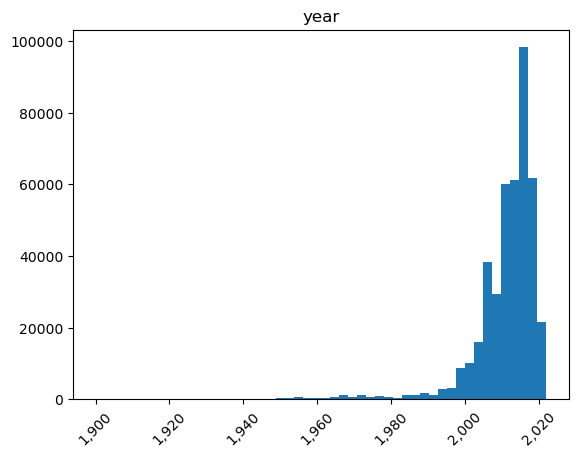

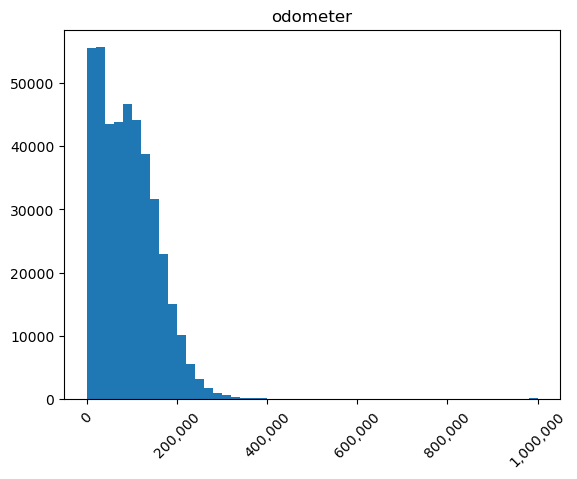

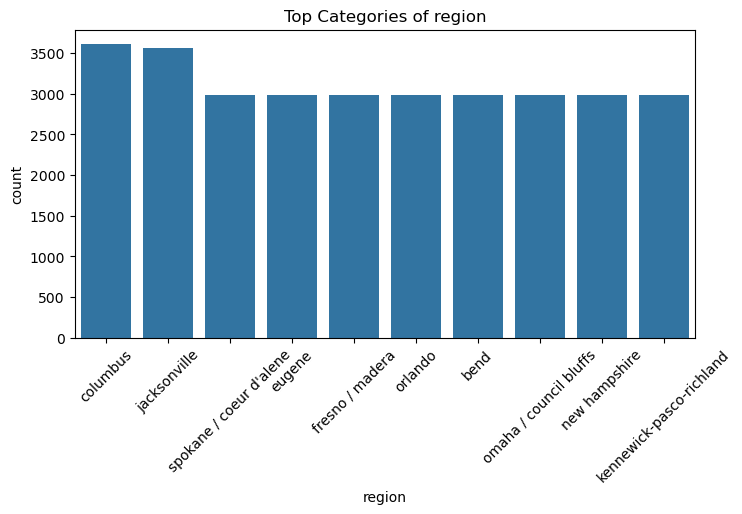

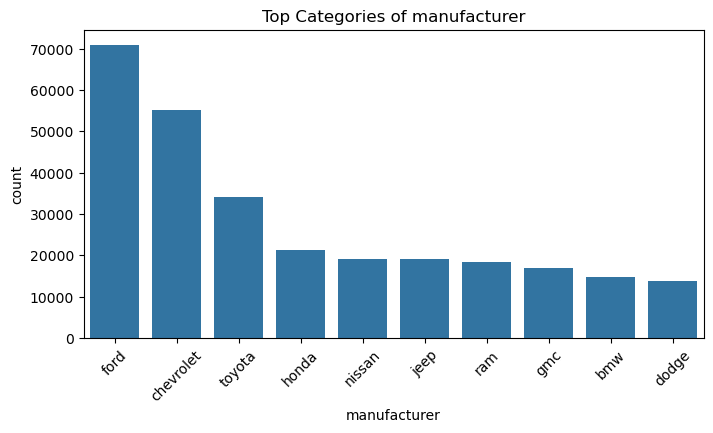

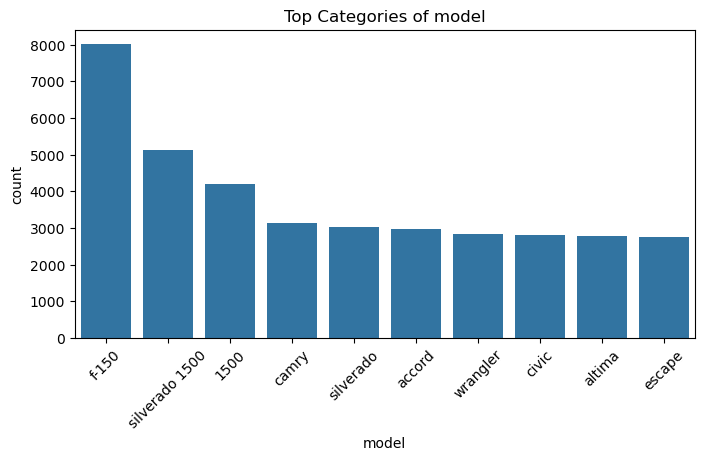

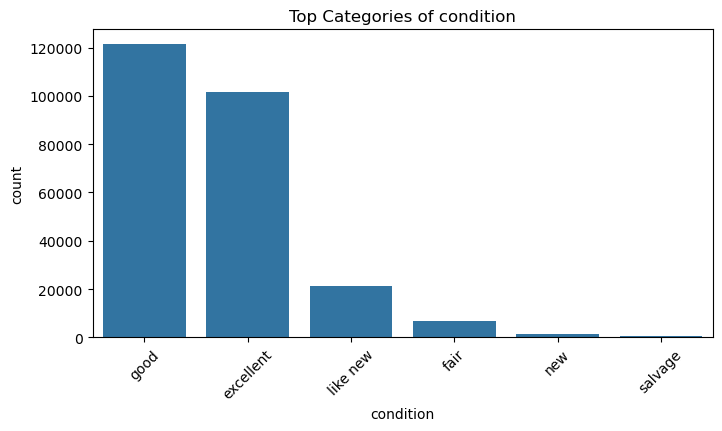

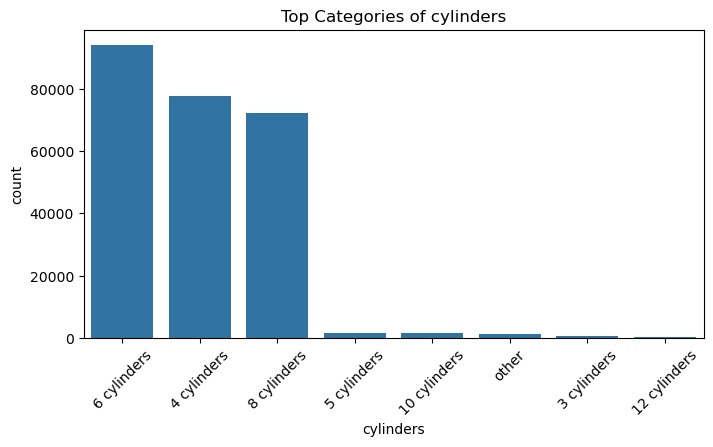

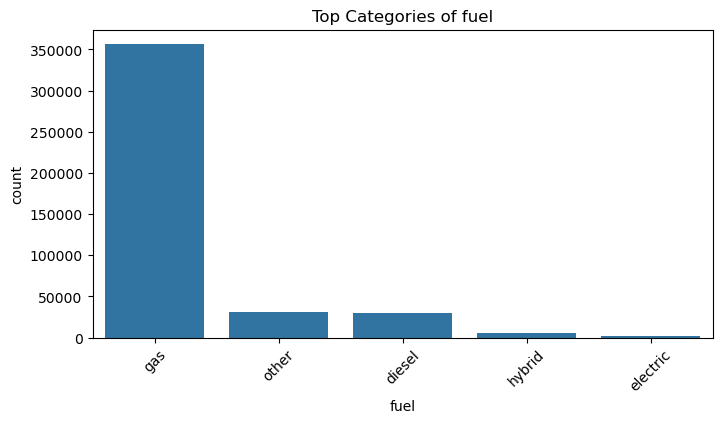

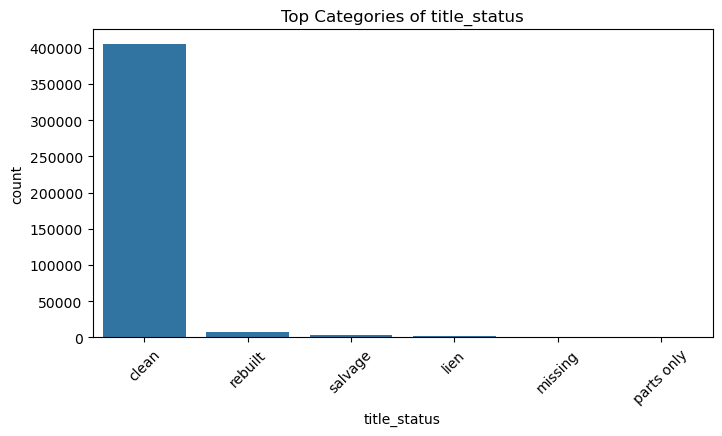

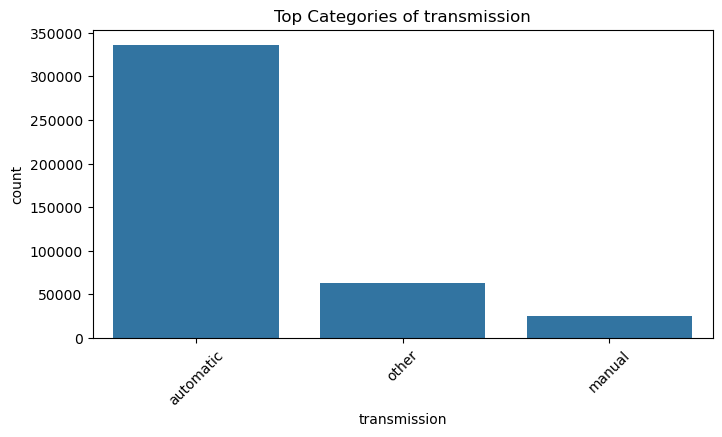

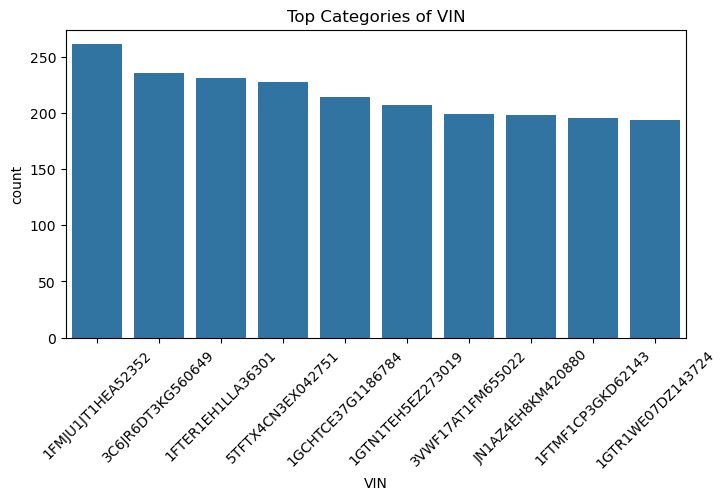

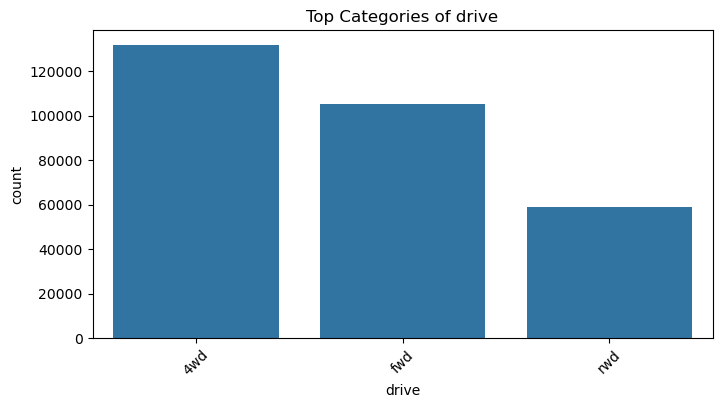

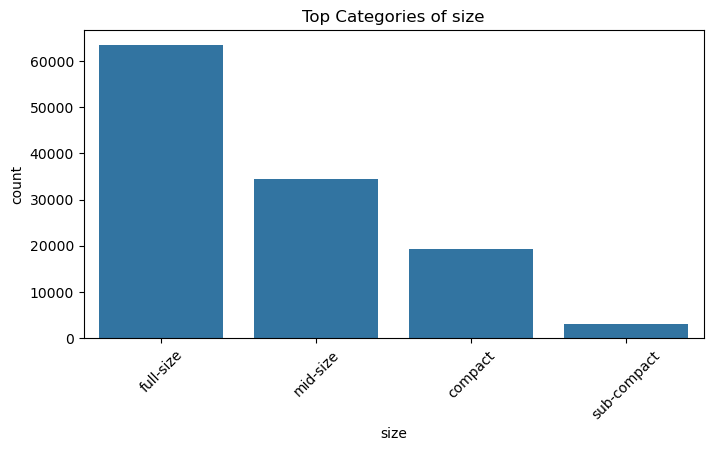

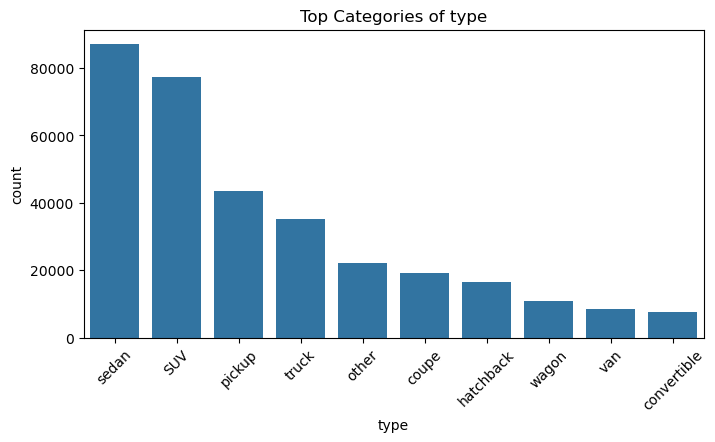

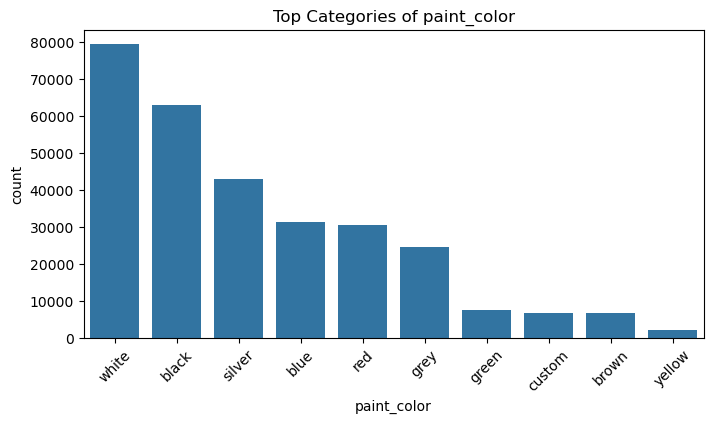

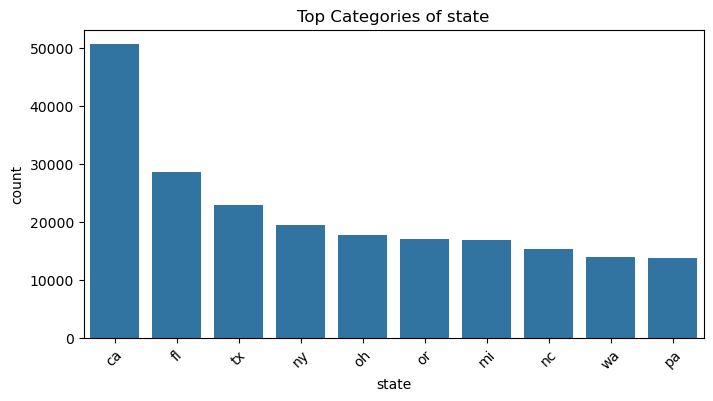

In [127]:
#generate histograms of columns
for col in num_cols:
    if col=='price':
        subset_df=used_cars[used_cars['price']<100000]
    if col=='odometer':       
        subset_df=used_cars[used_cars['odometer']<1000000]
    plt.hist(subset_df[col].dropna(), bins=50)   
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))    
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.title(col)
    # plt.savefig(f"hist_{col}.png", dpi=300, bbox_inches="tight")
    # plt.close()
    plt.show()

#generate countplots
for col in cat_cols:   
    top_categories = used_cars[col].value_counts().nlargest(10).index    
    plt.figure(figsize=(8,4))
    sns.countplot(
        data=used_cars[used_cars[col].isin(top_categories)],
        x=col,
        order=top_categories
    )    
    plt.xticks(rotation=45)
    plt.title(f"Top Categories of {col}")
    # plt.savefig(f"count_{col}.png", dpi=300, bbox_inches="tight")
    # plt.close()
    plt.show()

#findings:
#price: right-skewed, with the majority of cars having prices less than 40,000
#year: left-skewed distribution, with the majority of cars made after 2000
#odometer: right-skewed distribution, with the majority of cars having mileage of less than 200,000
#region: the number of cars seems to be fairly similar among the top 10 regions, with around 3,000–3,500 cars
#manufacturer: Ford and Chevrolet are the top manufacturers, with >50,000 cars
#model: F-150 is the most common model, followed by Silverado 1500
#condition: the majority of cars are in good/excellent condition
#cylinders: the majority of cars have 4, 6, or 8 cylinders
#fuel: the majority of cars run on gas
#title status: the majority of cars have a clean title
#transmission: the majority of cars have an automatic transmission, followed by manual and other
#drive: the majority of cars have 4WD, followed by FWD and RWD
#size: most cars are full-size, followed by mid-size and compact
#type: the most common car types are sedan and SUV, followed by pickup and truck
#paint_color: the most common car color is white, followed by black, silver, and blue
#state: the majority of cars belong to CA, followed by FL, TX, and NY


In [15]:
##Check for Outliers and Inconsistencies
#Detect unusual or unrealistic values (e.g., negative prices, extremely high mileage) 

print(used_cars.describe())
#no negative values found for prices, other numeric variables also seem to be reasonable


                 id         price           year      odometer
count  4.268800e+05  4.268800e+05  425675.000000  4.224800e+05
mean   7.311487e+09  7.519903e+04    2011.235191  9.804333e+04
std    4.473170e+06  1.218228e+07       9.452120  2.138815e+05
min    7.207408e+09  0.000000e+00    1900.000000  0.000000e+00
25%    7.308143e+09  5.900000e+03    2008.000000  3.770400e+04
50%    7.312621e+09  1.395000e+04    2013.000000  8.554800e+04
75%    7.315254e+09  2.648575e+04    2017.000000  1.335425e+05
max    7.317101e+09  3.736929e+09    2022.000000  1.000000e+07


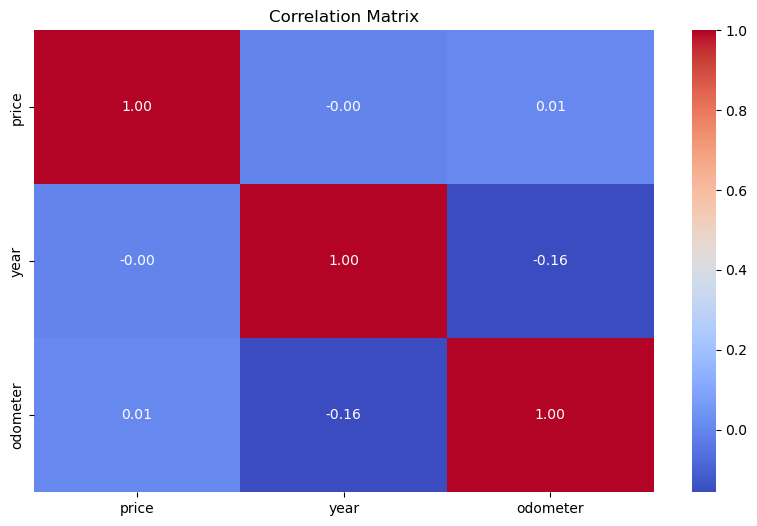

In [64]:
#check the correlation  
corr = used_cars[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#The heatmap shows that year (when the car was made) has almost no correlation with price.
#A higher odometer reading is also not significantly related to price, as the correlation is very close to zero.

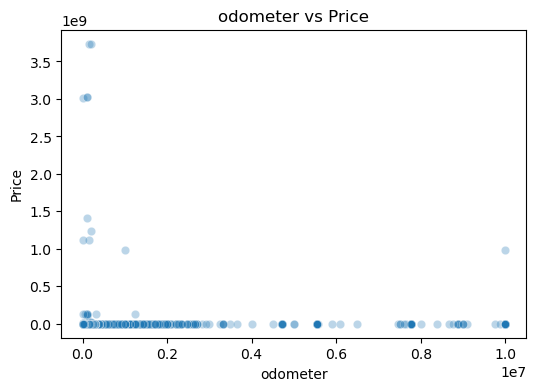

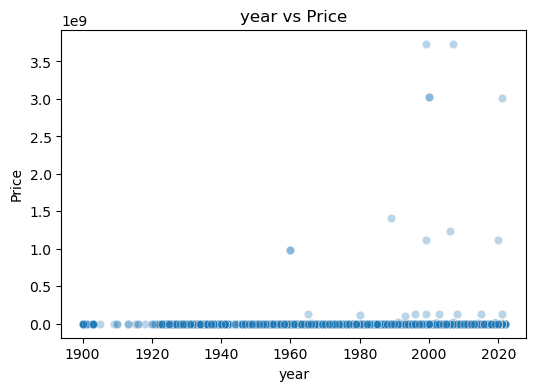

In [65]:
#scatterplot displaying the relationship between price and other variables

key_num_cols = ['odometer', 'year']  # adjust based on your dataset

for col in key_num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=used_cars[col], y=used_cars['price'], alpha=0.3)
    plt.title(f'{col} vs Price')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.show()

#scatterplot shows as the odometer reading increases the price decreases
#scatterplot shows as the year of make of the car increases the price increases (cars made is recent years have a higher price)

In [66]:
#understand how the categorical variables are related to the price
for col in cat_cols:
   
    top_categories = used_cars[col].value_counts().nlargest(10).index    
    plt.figure(figsize=(8,4))

    subset = used_cars[used_cars[col].isin(top_categories)]
    #restrict to price <1000000
    subset_price=subset[subset['price'] < 100000]
    
    sns.boxplot(x=subset_price[col], y=subset_price['price'])    
    plt.xticks(rotation=45)
    plt.title(f"Top Categories of {col}")
    #plt.savefig(f"plot_price_{col}.png", dpi=300, bbox_inches="tight")
    #plt.close()
    plt.show()


#findings:
#note: all findings are among the top 10 count values for each category
#region: there are no substantial differences in the prices of cars by region
#manufacturer: there are some substantial differences in the range of prices by manufacturer; Ram has slightly higher prices
#model: there are some substantial differences in the range of prices by model; some models like Camry have a slightly lower range of prices
#condition: the range of prices varies by category; cars with fair/salvage conditions have lower prices
#cylinders: no major differences in price by cylinder type; 12-cylinder cars have slightly higher prices
#fuel: cars that run on diesel, followed by electric cars, have slightly higher prices
#title status: lower prices are seen in cars with missing titles or listed as parts only
#transmission: automatic and manual transmission cars have similar prices
#drive, size, type, paint_color and state: no major differences are seen in prices by each of these categories


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [130]:
#remove outliers for price
p9999_price = used_cars['price'].quantile(0.9999)
p100_price = used_cars['price'].quantile(1)
print(p9999_price)
print(p100_price)

#restrict to cars having prices less than 99.99% (~125000) and price >0
used_cars_data=used_cars[(used_cars['price'] <= p9999_price) & (used_cars['price'] > 0)].copy()
print(f"shape of used cars {used_cars.shape}")
print(f"shape of used cars after removing price outliers {used_cars_data.shape}")


1234567.0
3736928711.0
shape of used cars (426880, 18)
shape of used cars after removing price outliers (393950, 18)


In [131]:
#convert year variable to categorical
used_cars_data = used_cars_data.copy()
current_year = datetime.now().year
used_cars_data['car_age'] = current_year - used_cars_data['year']
used_cars_data = used_cars_data.drop(columns=['year'])

print(used_cars_data['car_age'].describe())

cat_cols = list(cat_cols)  
cat_cols.append('car_age')
print(type(cat_cols))

count    392777.000000
mean         14.992808
std           9.627969
min           4.000000
25%           9.000000
50%          13.000000
75%          18.000000
max         126.000000
Name: car_age, dtype: float64
<class 'list'>


In [132]:
#use one hot encoding to convert variables to indicator variables
#get the number of unique values before doing one hot encoding
print("unique obs")
for col in cat_cols:    
    print(f"{col} ={used_cars_data[col].nunique()}")

#columns with large number of categorical variables like Vin can be dropped
used_cars_data=used_cars_data.drop(['VIN'], axis=1)
#the model has 29644 categories but seems like a relevant feature so keep it in

unique obs
region =404
manufacturer =42
model =28260
condition =6
cylinders =8
fuel =5
title_status =6
transmission =3
VIN =105809
drive =3
size =4
type =13
paint_color =12
state =51
car_age =112


In [133]:
#split the data into train and test
y_log=np.log(used_cars_data['price'])
y_raw=used_cars_data['price']

In [134]:
cat_cols = [col for col in cat_cols if col not in ['VIN']]
num_cols=['odometer']

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),     
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),   
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

cat_cols_with_model=cat_cols
cat_cols_without_model=[col for col in cat_cols if col != 'model']

preprocessor_with_model = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols_with_model)
])

preprocessor_without_model = ColumnTransformer([
    ('num', num_pipeline, num_cols),    
    ('cat', cat_pipeline, cat_cols_without_model)
])

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [135]:
#create a dataset with features used for predicting
X = used_cars_data.drop(columns=['price', 'VIN'], errors='ignore')


In [136]:
#split the data into train and test
X_train, X_test, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

_, _, y_train_r, y_test_r = train_test_split(
    X, y_raw, test_size=0.2, random_state=42
)


In [137]:
#Pipelines
pipe_lr = Pipeline([
    ('preprocess', preprocessor_with_model),
    ('model', LinearRegression())
])

pipe_lr_wo_model = Pipeline([
    ('preprocess', preprocessor_without_model),
    ('model', LinearRegression())
])

pipe_ridge = Pipeline([
    ('preprocess', preprocessor_with_model),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.1, 1, 10]
}

In [138]:
best_models={}
results = {}

models = {
    "Model 1 (Log, All features)": (pipe_lr, X_train, y_log_train, X_test, y_log_test),
    "Model 2 (Log, drop model)": (pipe_lr_wo_model, X_train.drop(columns=['model'], errors='ignore'),
                                 y_log_train,
                                 X_test.drop(columns=['model'], errors='ignore'),
                                 y_log_test),
    "Model 3 (Log, Ridge)": (pipe_ridge, X_train, y_log_train, X_test, y_log_test),
    "Model 4 (Raw, Ridge)": (pipe_ridge, X_train, y_train_r, X_test, y_test_r)
}

In [139]:
for name, (pipe, Xtr, ytr, Xte, yte) in models.items():
    
    if "Ridge" in name:
        grid = GridSearchCV(
            pipe,
            param_grid,
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        grid.fit(Xtr, ytr)
        best_model = grid.best_estimator_
        best_params = grid.best_params_
        
    else:
        best_model = pipe.fit(Xtr, ytr)
        best_params = None
    
    preds = best_model.predict(Xte)
    
    rmse = np.sqrt(mean_squared_error(yte, preds))
    r2 = r2_score(yte, preds)
    
    results[name] = {
        "RMSE": rmse,
        "R2": r2,
        "Best Params": best_params
    }

    best_models[name] ={
        "model_object": best_model
    }

In [140]:
results

{'Model 1 (Log, All features)': {'RMSE': 0.9518771444140245,
  'R2': 0.4348425899972004,
  'Best Params': None},
 'Model 2 (Log, drop model)': {'RMSE': 1.0268266285665888,
  'R2': 0.342339325817292,
  'Best Params': None},
 'Model 3 (Log, Ridge)': {'RMSE': 0.9493625779828126,
  'R2': 0.4378245898725648,
  'Best Params': {'model__alpha': 1}},
 'Model 4 (Raw, Ridge)': {'RMSE': 14243.1292018232,
  'R2': 0.4850271759933571,
  'Best Params': {'model__alpha': 0.1}}}

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [141]:
##key takeaways from the above model results

#The ridge model with all features included (R2 = 0.438, RMSE = 0.949) has a slightly better model fit compared to the linear regression model with all features (R2 = 0.435, RMSE = 0.952) and the linear regression model that drops the 'model' feature (R2 = 0.342, RMSE = 1.027); however, the improvement over linear regression is marginal.
#The linear regression model including all features (R2 = 0.435) performs significantly better than the model that excludes the 'model' feature (R2 = 0.342), indicating that 'model' is an important predictor.
#The model using the raw price (Ridge, R2 = 0.485, RMSE = 14243) has a higher R2 compared to the log-transformed models (R2 ≈ 0.435–0.438), indicating better overall explanatory power.
#However, the log-transformed models have lower RMSE in log space (~0.95) and may be more stable and robust, particularly in handling skewness and reducing the impact of outliers.

In [142]:
#identify the features driving the prices
model=best_models['Model 3 (Log, Ridge)']['model_object']
reg = model.named_steps['model']

coef_df = pd.DataFrame({
    'feature': model.named_steps['preprocess'].get_feature_names_out(),
    'coef': model.named_steps['model'].coef_
    }).sort_values(by='coef', ascending=False)

print("all coefs")
print(coef_df.head(20))
print(coef_df.tail(20))

print("all non-model coefs")
non_model = coef_df[~coef_df['feature'].str.contains('model')]


print(non_model.head(50))
print(non_model.tail(50))

#findings:
#Looking at the top and bottom outputs, it appears that the model of the car is a key feature in determining price.
#Other than the model, the car's manufacturer and age seem to be major factors driving price.
#Additionally, the car's condition, number of cylinders, and region are among the other factors impacting price.

all coefs
                                                 feature      coef
3854                       cat__model_Any make any model  4.259903
5241                      cat__model_Lamborghini Huracan  3.977684
5851                      cat__model_ROLLS ROYCE PHANTOM  2.998847
24451                             cat__model_viper rt/10  2.910579
5239                     cat__model_Lamborghini Gallardo  2.798660
12026  cat__model_excursion 4x4 limited 6.8l v10 gas ...  2.656823
9651                       cat__model_commercial chassis  2.653955
24447                                   cat__model_viper  2.640863
12982  cat__model_f-450 4x2 truck w/new crysteel 11' ...  2.503244
16359                    cat__model_lamborghini gallardo  2.488813
19467                                 cat__model_r8 5.2l  2.416646
24448                       cat__model_viper convertible  2.405746
5202                            cat__model_Kenworth W900  2.350048
5243                  cat__model_Lamborghini huracan

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [ ]:
#please refer the readme document for the findings and recommendations